---
# T. E. R. : __IMPACT OF EXCESS-OF-LOSS REINSURANCE ON CATASTROPHE RISK IN NON-LIFE INSURANCE__

## Data Process Treatment

**ANTOINE DERRIEN** : antoine.derrien@etu.univ-lyon1.fr

**SAMUEL TORT** : samuel.tort@etu.univ-lyon1.fr

**MAHLÎ REINETTE** : mahli.reinette@etu.univ-lyon1.fr

---

In [43]:
#Dependant Libraries
from scipy.stats import norm
import random as rd
import numpy as np
import math
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import kaleido
import plotly.io as pio
from collections.abc import Callable
from scipy.fft import fft, ifft, fftfreq
from scipy import stats
from scipy.stats import gamma
import csv
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
print("all dependancies statut: ok")

all dependancies statut: ok


In [6]:
np.random.seed(42)
print(np.random.rand(3))

[0.37454012 0.95071431 0.73199394]


In [7]:
intensity_normalization_dict = {1 : [31, 31],
                               2 : [28, 29],
                               3 : [31, 31],
                               4 : [30, 30],
                               5 : [31, 31],
                               6 : [30, 30],
                               7 : [31, 31],
                               8 : [31, 31],
                               9 : [30, 30],
                               10 : [31, 31],
                               11 : [30, 30],
                               12 : [31, 31]}
d_by_y = [365, 366]
def intensity_normalization():
    new_data = {}
    with open('new_data.csv', mode ='r') as file:
        csvFile = csv.reader(file)
        for lines in csvFile:
            if lines[0] != '':
                line = lines[1]
                y, m, d = int(line[:4]), int(line[5:7]), int(line[8:])
                b = (((y % 4)==0)and((y % 100) !=0))or((y%400)==0) #Is the year bisextile
                s = 0
                for i in range(1, m-1):
                    s = s + intensity_normalization_dict[m][b]
                s = s + d + rd.random() #We need this for our poisson model 
                if y in new_data:
                    new_data[y][0].append(s/d_by_y[b])
                    new_data[y][1].append(float(lines[2]))
                else:
                    new_data[y] = [[s/d_by_y[b]], [float(lines[2])]]
    return new_data

In [8]:
my_data = intensity_normalization()
print("cover dates: " + str(list(my_data.keys())))
print("registers: " + str([len(my_data[key][0]) for key in my_data.keys()]))
print("min-max (2024): " + str([min(my_data[2024][0]), max(my_data[2024][0])]))
print("min-max (2023): " + str([min(my_data[2023][0]), max(my_data[2023][0])]))
print("min-max (2022): " + str([min(my_data[2022][0]), max(my_data[2022][0])]))

cover dates: [2024, 2023, 2022]
registers: [1111, 2309, 1080]
min-max (2024): [0.0028141726037676017, 0.447062556503449]
min-max (2023): [0.003002257073146872, 0.9366071188662018]
min-max (2022): [0.45008634509400636, 0.9364593058680274]


---

The data from 2022 and 2024 seem incomplete. Furthermore, they appear to have been split in two, with the records of one seemingly being the continuation of the other.

We have decided to merge them.

---

In [9]:
merged_datas = {2023 : my_data[2023],
               2024 : [my_data[2024][0] + my_data[2022][0], my_data[2024][1] + my_data[2022][1]]}

In [10]:
print("cover dates: " + str(list(merged_datas.keys())))
print("registers: " + str([len(merged_datas[key][0]) for key in merged_datas.keys()]))
print("min-max (2024): " + str([min(merged_datas[2024][0]), max(merged_datas[2024][0])]))
print("min-max (2023): " + str([min(merged_datas[2023][0]), max(merged_datas[2023][0])]))

cover dates: [2023, 2024]
registers: [2309, 2191]
min-max (2024): [0.0028141726037676017, 0.9364593058680274]
min-max (2023): [0.003002257073146872, 0.9366071188662018]


---

### Let's check if the dates are sorted.

---

In [11]:
test = merged_datas[2024][0].copy()
test.sort()
merged_datas[2024][0] == test

False

In [12]:
def sort_data_set(data_set : [[float]]):
    sorted_dates = data_set[0].copy()
    sorted_dates.sort()
    n = len(sorted_dates)
    maping = dict(zip(sorted_dates, [i for i in range(n)]))
    sorted_sinisters = [0 for i in range(n)]
    for i in range(n):
        sorted_sinisters[maping[data_set[0][i]]] = data_set[1][i]
    return [sorted_dates, sorted_sinisters]

In [13]:
sorted_merged_data = {2023 : sort_data_set(merged_datas[2023]),
                     2024 : sort_data_set(merged_datas[2024])}

In [14]:
print("cover dates: " + str(list(sorted_merged_data.keys())))
print("registers: " + str([len(sorted_merged_data[key][0]) for key in sorted_merged_data.keys()]))
print("min-max (2024): " + str([min(sorted_merged_data[2024][0]), max(sorted_merged_data[2024][0])]))
print("min-max (2023): " + str([min(sorted_merged_data[2023][0]), max(sorted_merged_data[2023][0])]))

cover dates: [2023, 2024]
registers: [2309, 2191]
min-max (2024): [0.0028141726037676017, 0.9364593058680274]
min-max (2023): [0.003002257073146872, 0.9366071188662018]


In [15]:
test = sorted_merged_data[2024][0].copy()
test.sort()
print(sorted_merged_data[2024][0] == test)
test = sorted_merged_data[2023][0].copy()
test.sort()
print(sorted_merged_data[2023][0] == test)

True
True


---

### Second, individual claim amounts $S_i$ are assumed i.i.d. and independent of the claim time $t_i$

---

In [16]:
print("covariance of 2023: " + str(pearsonr(sorted_merged_data[2023][0], sorted_merged_data[2023][1])[1]))
print("covariance of 2024: " + str(pearsonr(sorted_merged_data[2024][0], sorted_merged_data[2024][1])[1]))

covariance of 2023: 0.015096543780400313
covariance of 2024: 0.5233801755596814


---

### Since the p-value of our Pearson test is not significant, we can confirm our independence hypothesis.

---

In [17]:
class empiricalJumps():
    def __init__(self, T : [float], horizon=None):
        """
        T : times of jumps
        horizon :  ℓ, limite of record
        subdivision : number of subdivisions k
        """
        self.T = T.copy()
        self.T.append(0) #add t_0
        self.T.sort()
        if horizon==None:
            self.horizon = self.T[-1]
        else:
            self.horizon = horizon
        self.T.append(self.horizon)
        self.n = len(self.T)
        self.subdivision = self.optimize_step()

        
        #We initialize the dictionnary
        self.map = dict(zip([(v/self.subdivision)*self.horizon for v in range(self.subdivision+1)],[{} for v in range(self.subdivision+1)]))
        self.initialize() # we fill the dictionnary
        pass
    def initialize(self):
        """
        we classify all the jumps with the classyfier function
        """
        #self.T has been sorted, so we can 
        patch = list(self.map.keys())
        patch.append(self.horizon)
        i = 0
        #i, k = 0, 0
        for k in range(len(patch)-1):
            if (i < self.n - 1):
                if (patch[k] < self.T[i+1])and(self.T[i+1] < patch[k+1]):
                    self.map[patch[k]][self.T[i]] = i
                    i = i + 1
                    self.map[patch[k]][self.T[i]] = i
                elif (patch[k] == self.T[i+1]):
                    i = i + 1
                    self.map[patch[k]][self.T[i]] = i
                else:
                    self.map[patch[k]][self.T[i]] = i
    def optimize_step(self):
        """
        We want a maximum of 2 records betweens our steps, so we need to callibrate the right numbers of steps (this solution is not optimal)
        """
        return int(self.horizon/min([self.T[i+1]-self.T[i] for i in range(self.n-1)])) + 1
        pass
    def R_t(self, t : float):
        """
        Get R_t value, in O(1)
        """
        call = int(self.subdivision*t)/self.subdivision
        if call not in self.map:
            return (self.horizon <= call)*self.T[-1]
        else:
            local_times = list(self.map[call].keys())
            if len(local_times) > 1:
                return (self.horizon <= call)*self.T[-1] + ((len(local_times) == 1)or(t<local_times[1]))*self.map[call][local_times[0]] + (local_times[1] <= t)*self.map[call][local_times[1]]
            else:
                return (self.horizon <= call)*self.T[-1] + (len(local_times) == 1)*self.map[call][local_times[0]]
    def drawEmpiricalProcess(self):
        """
        Draw the Poisson Process
        """
        a = [i for i in range(self.n)]
        a[-1] = a[-2]
        fig = px.ecdf(a, x=self.T, ecdfmode="standard", title="Poisson Process", ecdfnorm=None, template="plotly_dark")
        fig.show()
    def __repr__(self):
        self.drawEmpiricalProcess()
        return "____________EMPIRiCAL RECORDS____________ \n" + "    n : " + str(self.n - 2) + ", number of records\n" + "    ℓ : " + str(self.horizon) + ", horizon\n" + "    k : " + str(self.subdivision) + ", number of subdivisions"
    def __str__(self):
        self.drawEmpiricalProcess()
        return "____________EMPIRiCAL RECORDS____________ \n" + "    n : " + str(self.n - 2) + ", number of records\n" + "    ℓ : " + str(self.horizon) + ", horizon\n" + "    k : " + str(self.subdivision) + ", number of subdivisions"

In [18]:
trajectory_jumps = [empiricalJumps(T=sorted_merged_data[2023][0], horizon=1), empiricalJumps(T=sorted_merged_data[2024][0], horizon=1)]
for trajectory in trajectory_jumps:
    print(trajectory)

____________EMPIRiCAL RECORDS____________ 
    n : 2309, number of records
    ℓ : 1, horizon
    k : 8601253, number of subdivisions


____________EMPIRiCAL RECORDS____________ 
    n : 2191, number of records
    ℓ : 1, horizon
    k : 20053990, number of subdivisions


---

Two main points: first, the intensity does not appear to be constant; second, the intensity looks similar from one year to the next, confirming our intuition to set a 1-year horizon.

---

In [19]:
class Local_Model():
    def __init__(self, bandwidth : float, horizon : float, m : int):
        """
        bandwidth : ♭, Bias-Variance/Bandwidth
        horizon :  ℓ, limite of record
        m : local monte carlo frequency
        """
        self.bandwidth = bandwidth
        self.horizon = horizon
        self.m = m
        pass
    def __repr__(self):
        return "__Local__Model__  M(♭, ℓ, m) : \n" + "♭ : " + str(self.bandwidth) + "\n" + "ℓ : " + str(self.horizon) + "\n" + "m : " + str(self.m)
    def __str__(self):
        return "__Local__Model__  M(♭, ℓ, m) : \n" + "♭ : " + str(self.bandwidth) + "\n" + "ℓ : " + str(self.horizon) + "\n" + "m : " + str(self.m)
class get_local_estimator():
    def __init__(self, R_points : [int], t_points : [float], n : int, alpha : float):
        """
        R_points : (R_t_0, R_t_1, ..., R_t_n), values record
        t_points : (t_0, t_1, ..., t_n), times record
        Estimator of the local intensity Rn*((t_1, t_2, ..., t_n))
        Recall : 
            R_t_0 = 0
            t_0 = 0
        """
        assert len(R_points) == len(t_points), "not equal number of measures"
        self.R_points = R_points
        self.t_points = t_points
        self.n = n 
        self.estimator = 0
        self.alpha = alpha
        for indice in range(self.n - 1):
            try:
                self.estimator = self.estimator + (self.R_points[indice+1] - self.R_points[indice])/(self.t_points[indice+1] - self.t_points[indice])
            except:
                print("error : (" + str(self.t_points[indice+1]) + " - " + str(self.t_points[indice]) + ")")
        self.estimator = (1/self.n)*self.estimator
        point = norm.ppf(1-self.alpha/2, loc=0, scale=1)*math.sqrt(self.estimator/self.n)
        self.assym_confidence_interval = [-point, point]
    def __repr__(self):
        return "____________LOCAL  ESTIMATOR____________ \n" + "    __number__of__observations__ : " + str(self.n) + "\n" + "    __estimation__ : " + str(self.estimator)[:8] + "\n" + "    __assymptotique confidence interval__ ]({" + str(1-self.alpha) + "})[ : [" + str(self.estimator + self.assym_confidence_interval[0]) + ", " + str(self.estimator + self.assym_confidence_interval[1]) + "] \n"
    def __str__(self):
        return "____________LOCAL  ESTIMATOR____________ \n" + "    __number__of__observations__ : " + str(self.n) + "\n" + "    __estimation__ : " + str(self.estimator)[:8] + "\n" + "    __assymptotique confidence interval__ ]({" + str(1-self.alpha) + "})[ : [" + str(self.assym_confidence_interval[0]) + ", " + str(self.assym_confidence_interval[1]) + "] \n"
def ressample(Measures : [[float]]):
    """
    We need to sort the occurence times and had t_0
    """
    for measure in Measures:
        measure.append(0)
        measure.sort()
def I(T : [float], X : [float]):
    """
    Approximate the value of the X(t), with the rectangles method
    """
    v= [X[0]*(T[1] - T[0])]
    for i in range(1,len(T)-1):
        v.append(v[-1] + X[i]*(T[i+1]-T[i]))
    v.append(v[-1])
    return np.array(v)
class Global_Local_Model_Regular_Sampling(Local_Model):
    def __init__(self, bandwidth : float, horizon : float, m : int, T : [float], alpha : float, k : int):
        """
        bandwidth : ♭, Bias-Variance/Bandwidth
        horizon :  ℓ, limite of record
        m : local monte carlo frequency
        k : number of local intensities
        alpha : quantile for confidence interval
        Regular Sampling
        """
        assert (alpha < 1)and(alpha > 0), "alpha need to be include in ]0, 1["
        super().__init__(bandwidth=bandwidth, horizon=horizon, m=m)
        self.alpha = alpha
        self.T = T
        self.k = k
        self.empiricalJumps = empiricalJumps(T=self.T, horizon=self.horizon)
        self.partition = [i/self.k for i in range(self.k)]
        self.measures = [[self.g(t + np.random.normal(0, self.bandwidth)) for i in range(self.m)] for t in self.partition]
        ressample(self.measures)
        self.local_estimators = [get_local_estimator(R_points=[self.empiricalJumps.R_t(t) for t in measure], t_points=measure, n=self.m, alpha=self.alpha) for measure in self.measures]
    def g(self, x : float):
        if (x<0):
            return self.g(-x)
        return (0 <= x)*(x <= self.horizon)*x + (self.horizon < x)*(self.horizon - abs(np.random.normal(0, self.bandwidth)))
    def draw_intensity(self):
        """
        draw the intensity function estimation with confidence intervall
        """
        fig = go.Figure(data=go.Scatter(
                x=self.partition,
                y=[measure.estimator for measure in self.local_estimators],
                error_y=dict(
                    type='data',
                    symmetric=False,
                    array=[measure.assym_confidence_interval[1] for measure in self.local_estimators],
                    arrayminus=[measure.assym_confidence_interval[0] for measure in self.local_estimators])
                ))
        fig.update_layout(
            title=dict(text="local intensity function, confidence interval : " + str(1 - self.alpha)),
            template="plotly_dark"
            )
        fig.show()
    def draw_global_intensity(self):
        """
        draw the integral of the intensity function estimation
        """
        fig = go.Figure(data=[go.Scatter(x=self.partition, y=I(T=self.partition, X=[measure.estimator for measure in self.local_estimators]))])
        # Use datetime objects to set xaxis range
        fig.update_layout(
            title=dict(text="intensity"),
            template="plotly_dark"
            )
        fig.show()
    def __repr__(self):
        self.draw_intensity()
        self.draw_global_intensity()
        return "____________GLOBAL  LOCAL  MODEL (Regular Sampling)____________ \n" + super().__repr__() + "\n" + self.empiricalJumps.__repr__() 
    def __str__(self):
        self.draw_intensity()
        self.draw_global_intensity()
        return "____________GLOBAL  LOCAL  MODEL (Regular Sampling)____________ \n" + super().__str__() + "\n" + self.empiricalJumps.__repr__() 

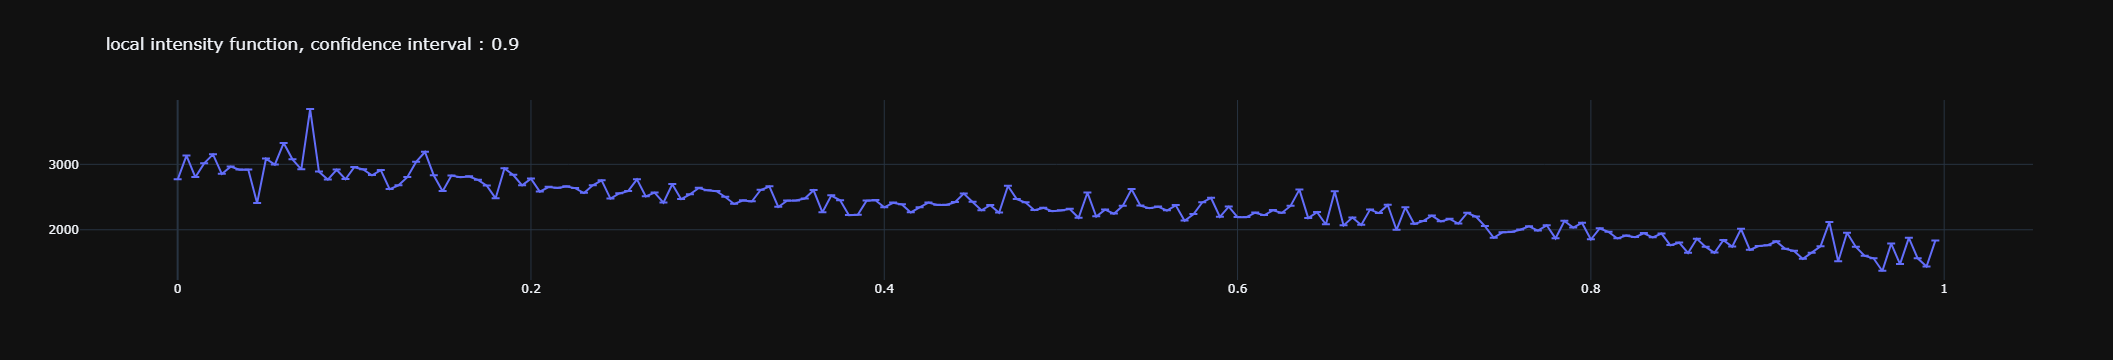

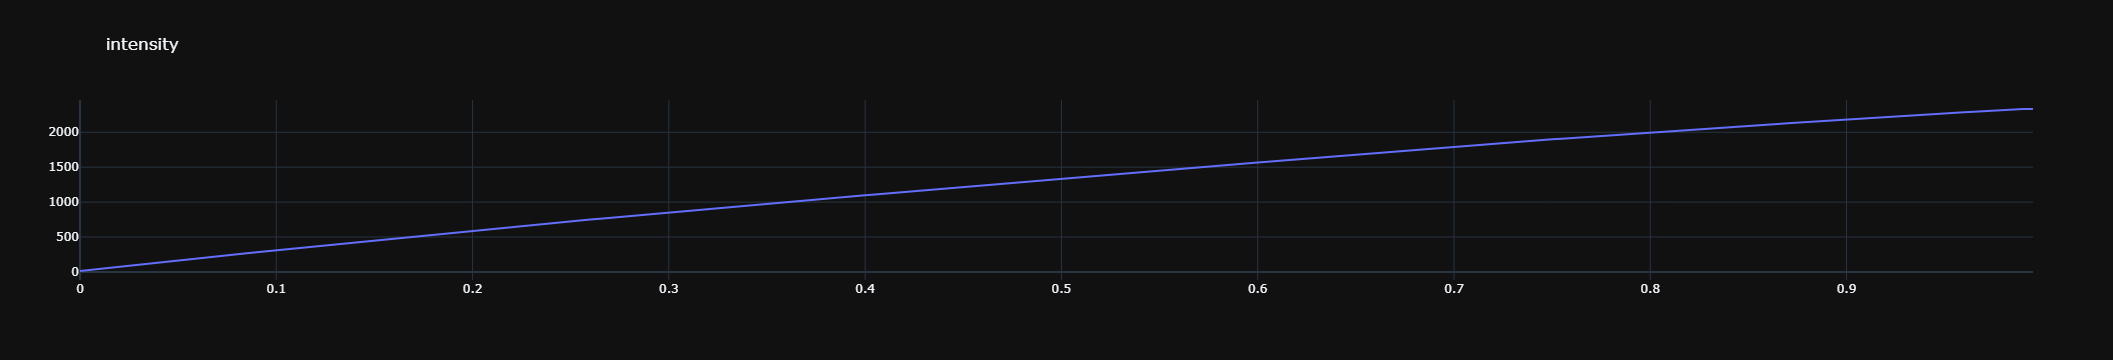

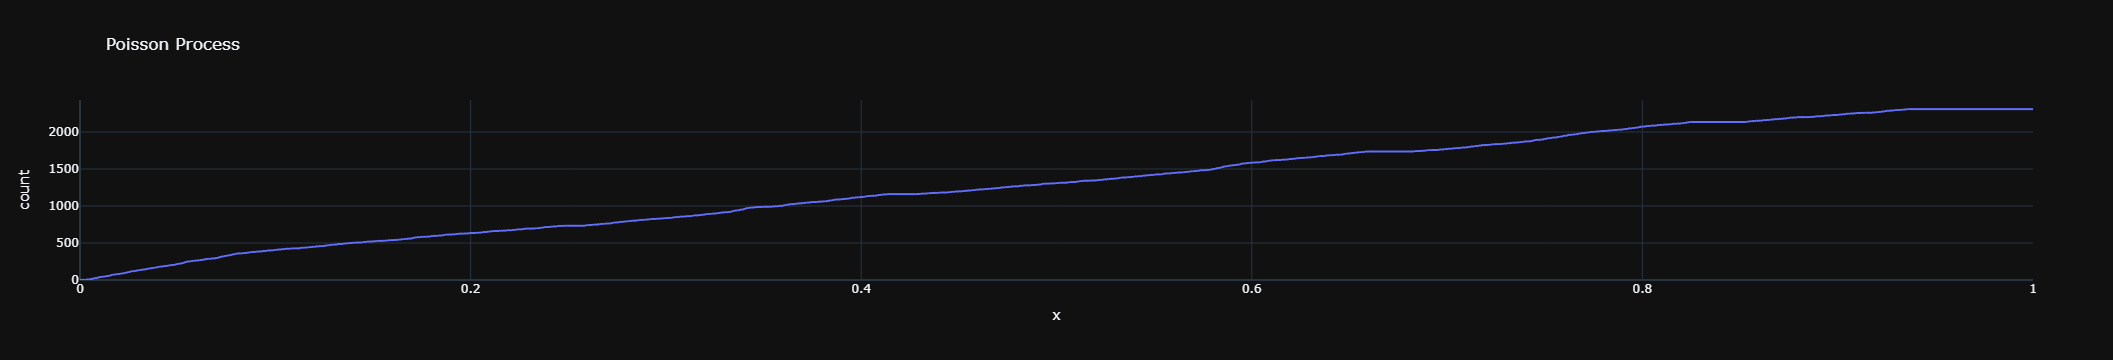

____________GLOBAL  LOCAL  MODEL (Regular Sampling)____________ 
__Local__Model__  M(♭, ℓ, m) : 
♭ : 0.2
ℓ : 1
m : 1000
____________EMPIRiCAL RECORDS____________ 
    n : 2309, number of records
    ℓ : 1, horizon
    k : 8601253, number of subdivisions


In [21]:
LOCAL_MODEL_2023 = Global_Local_Model_Regular_Sampling(bandwidth=0.2, horizon=1, m=1000, T=sorted_merged_data[2023][0], alpha=0.1, k=200)
print(LOCAL_MODEL_2023)

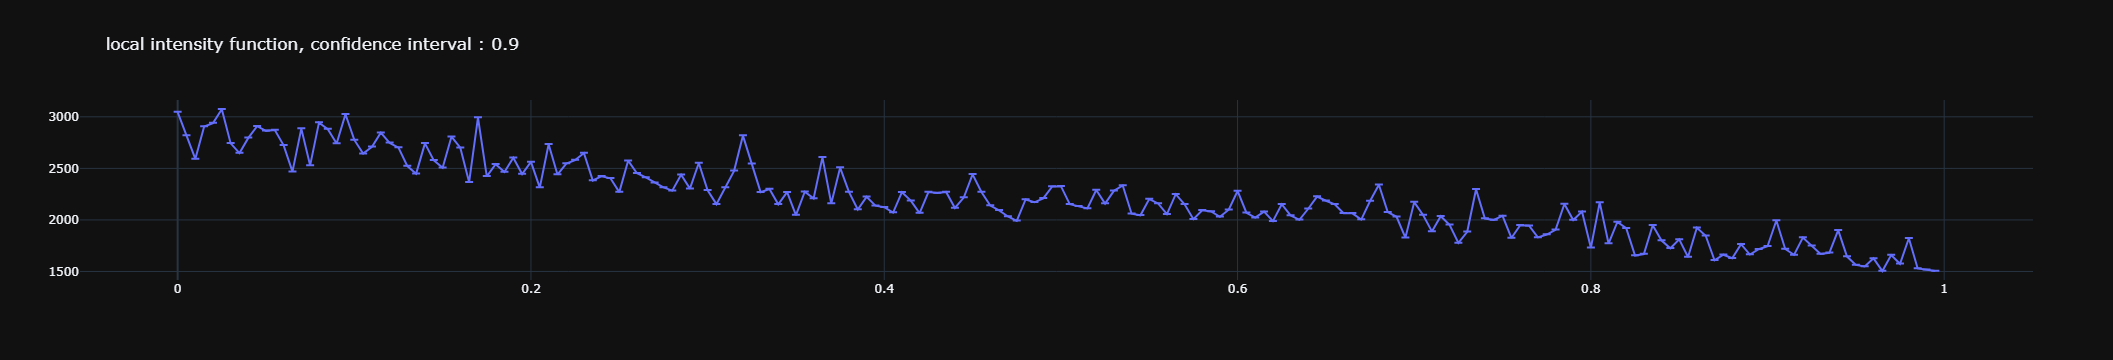

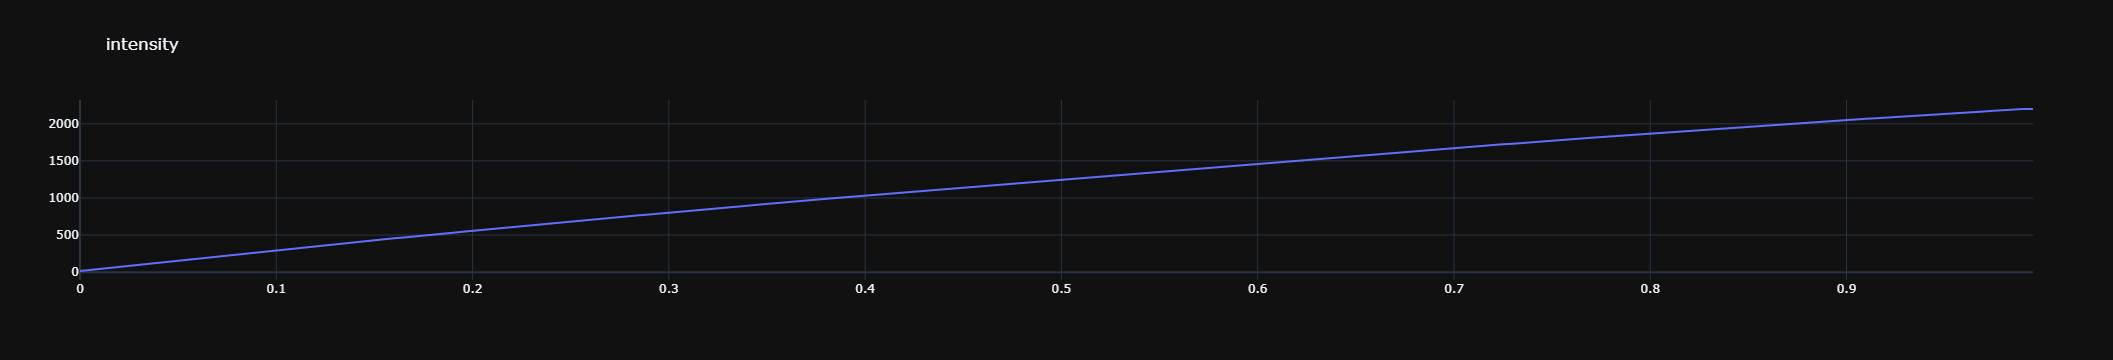

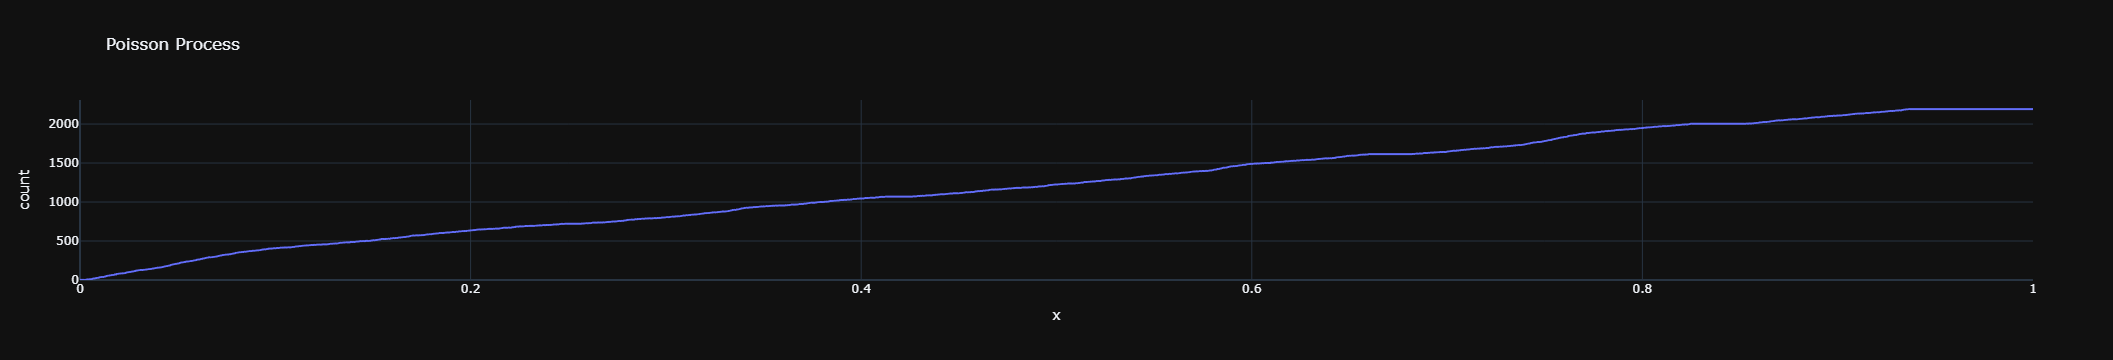

____________GLOBAL  LOCAL  MODEL (Regular Sampling)____________ 
__Local__Model__  M(♭, ℓ, m) : 
♭ : 0.2
ℓ : 1
m : 1000
____________EMPIRiCAL RECORDS____________ 
    n : 2191, number of records
    ℓ : 1, horizon
    k : 20053990, number of subdivisions


In [22]:
LOCAL_MODEL_2024 = Global_Local_Model_Regular_Sampling(bandwidth=0.2, horizon=1, m=1000, T=sorted_merged_data[2024][0], alpha=0.1, k=200)
print(LOCAL_MODEL_2024)

### We estimated our local intensity and it is clearly not constant (although it remains stable throughout our two years). The intensity seems to be linear, at least locally. To determine our coefficients, let's perform a linear regression on our local intensities.

In [30]:
model_01 = LinearRegression()
model_01.fit(np.array(LOCAL_MODEL_2023.partition).reshape(-1, 1), np.array([measure.estimator for measure in LOCAL_MODEL_2023.local_estimators]).reshape(-1, 1))
print(f"Slope (B1): {model_01.coef_[0]}")
print(f"Intercept (B0): {model_01.intercept_}")
print(f"R square: {model_01.score(np.array(LOCAL_MODEL_2023.partition).reshape(-1, 1), np.array([measure.estimator for measure in LOCAL_MODEL_2023.local_estimators]).reshape(-1, 1))}")

Slope (B1): [-1314.06544102]
Intercept (B0): [2995.83746278]
R square: 0.8492889989252058


In [45]:
X = (np.array(LOCAL_MODEL_2023.partition)).reshape(-1, 1)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
Y = np.array([measure.estimator for measure in LOCAL_MODEL_2023.local_estimators]).reshape(-1, 1)
model_03 = LinearRegression()
model_03.fit(X_poly, Y)
print(f"Slope (B1): {model_03.coef_[0]}")
print(f"Intercept (B0): {model_03.intercept_}")
print(f"R square: {model_03.score(X_poly, Y)}")

Slope (B1): [-1135.19542111  -179.76886424]
Intercept (B0): [2966.3239095]
R square: 0.8503485350523009


In [46]:
X = (np.array(LOCAL_MODEL_2023.partition)).reshape(-1, 1)
poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X)
Y = np.array([measure.estimator for measure in LOCAL_MODEL_2023.local_estimators]).reshape(-1, 1)
model_03 = LinearRegression()
model_03.fit(X_poly, Y)
print(f"Slope (B1): {model_03.coef_[0]}")
print(f"Intercept (B0): {model_03.intercept_}")
print(f"R square: {model_03.score(X_poly, Y)}")

Slope (B1): [-2462.23344206  2970.73039286 -1725.16094421  -338.78452767]
Intercept (B0): [3078.12291031]
R square: 0.8624946425258111


In [52]:
X = (np.array(LOCAL_MODEL_2023.partition)).reshape(-1, 1)
poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X)
Yp = np.array([math.log(measure.estimator) for measure in LOCAL_MODEL_2023.local_estimators]).reshape(-1, 1)
model_03 = LinearRegression()
model_03.fit(X_poly, Yp)
print(f"Slope (B1): {model_03.coef_[0]}")
print(f"Intercept (B0): {model_03.intercept_}")
print(f"R square: {model_03.score(X_poly, Yp)}")

Slope (B1): [-0.87536258  0.9956601  -0.45781317 -0.35815675]
Intercept (B0): [8.0329523]
R square: 0.8751151900374262


In [53]:
X = (np.array(LOCAL_MODEL_2024.partition)).reshape(-1, 1)
poly = PolynomialFeatures(degree=4, include_bias=False)
X_poly = poly.fit_transform(X)
Yp = np.array([math.log(measure.estimator) for measure in LOCAL_MODEL_2024.local_estimators]).reshape(-1, 1)
model_04 = LinearRegression()
model_04.fit(X_poly, Yp)
print(f"Slope (B1): {model_04.coef_[0]}")
print(f"Intercept (B0): {model_04.intercept_}")
print(f"R square: {model_04.score(X_poly, Yp)}")

Slope (B1): [-0.80666565  0.03856015  1.41507854 -1.30222663]
Intercept (B0): [7.98114344]
R square: 0.8720338595438357


In [54]:
model_05 = LinearRegression()
model_05.fit(np.array(LOCAL_MODEL_2024.partition).reshape(-1, 1), np.array([measure.estimator for measure in LOCAL_MODEL_2024.local_estimators]).reshape(-1, 1))
print(f"Slope (B1): {model_05.coef_[0]}")
print(f"Intercept (B0): {model_05.intercept_}")
print(f"R square: {model_05.score(np.array(LOCAL_MODEL_2024.partition).reshape(-1, 1), np.array([measure.estimator for measure in LOCAL_MODEL_2024.local_estimators]).reshape(-1, 1))}")

Slope (B1): [-1170.44010669]
Intercept (B0): [2789.61312116]
R square: 0.8475694801636037


In [56]:
Yp = np.array([math.log(measure.estimator) for measure in LOCAL_MODEL_2024.local_estimators]).reshape(-1, 1)
model_06 = LinearRegression()
model_06.fit(np.array(LOCAL_MODEL_2023.partition).reshape(-1, 1), Yp)
print(f"Slope (B1): {model_06.coef_[0]}")
print(f"Intercept (B0): {model_06.intercept_}")
print(f"R square: {model_06.score(np.array(LOCAL_MODEL_2023.partition).reshape(-1, 1), Yp)}")

Slope (B1): [-0.5354139]
Intercept (B0): [7.95199301]
R square: 0.8522675730315165


---

### We have better results on our 2023 data with our log-linear regression. To avoid overfitting, we will stick to our 2-parameter estimation.

$$ln(f_1(t)) = \beta_0 + \beta_1 t$$

$$\iff f_1(t) = exp(\beta_0 + \beta_1 t)$$

$$\iff F_1(t) = \dfrac{f(t)}{\beta_1} \text{, such that: } F_1^{'} = f_1 \iff \nabla_{f_1}(t) = F_1(t) - F_1(0) = \dfrac{f_1(t) - exp(\beta_0)}{\beta_1} = \dfrac{exp(\beta_0)(exp(\beta_1t) - 1)}{\beta_1}$$

---

In [58]:
class GeneralEsttimationModel():
    def __init__(self, T : [float], S : [float], f : callable, inte="", m_c_int=10000):
        """
        T: times of occurence (T need to be sorted)
        S: sinistrality
        inte: a callable, formal form of ∇ (if possible, enter None if it is not the case) 
        m_c_int: monte carlo frequency (if we dont have formal integral form)
        """
        self.T = T
        self.S = S
        self.f = f
        self.inte = inte
        self.m_c_int = m_c_int
        self.X = []
        self.n = len(self.T)
        self.initializeX()
        self.estimation = 0
        self.run_estimation()
        self.p_value = 0
        self.run_p_value()
        a, b = stats.shapiro([math.log(x) for x in self.S])
        self.sinistrality_p_value = b
        pass
    def initializeX(self):
        def norm_distrib(x : float):
            return (1/math.sqrt((2*math.pi)))*math.exp(-(x**2)/2)
        if (self.inte == ""):
            c = sum([self.f(x)*(x <= T[0])/norm_distrib(x) for x in [np.random.normal(0, 1) for i in range(self.m_c_int)]])/self.m_c_int
            self.X.append(c)
            for i in range(len(self.T)-1): 
                a, b = sum([self.f(x)*(x <= T[i+1])/norm_distrib(x) for x in [np.random.normal(0, 1) for i in range(self.m_c_int)]])/self.m_c_int, sum([self.f(x)*(x <= T[i])/norm_distrib(x) for x in [np.random.normal(0, 1) for i in range(self.m_c_int)]])/self.m_c_int
                self.X.append(a-b)
            pass
        else:
            self.X.append(self.inte(self.T[0]))
            for i in range(len(self.T)-1):
                self.X.append(self.inte(self.T[i+1]) - self.inte(self.T[i]))
        pass
    def run_estimation(self):
        self.estimation = sum(self.X)/len(self.X)
        print(self.estimation)
    def run_p_value(self):
        def factorial(n : int):
            if (n==0)or(n==1):
                return 1
            else:
                return n * factorial(n-1)
        self.p_value = gamma.sf(x=self.estimation, a=self.n, scale=1/self.n)
        pass
    def __repr__(self):
        return "____________CONTINUOUS MODEL____________ \n" + "    ----Test on intensity: " + str(self.p_value) + "---- \n" + "    ----Test on severity(shapiro test): " + str(self.sinistrality_p_value) + "---- \n"  
    def __str__(self):
        return "____________CONTINUOUS MODEL____________ \n" + "    ----Test on intensity: " + str(self.p_value) + "---- \n" + "    ----Test on severity(shapiro test): " + str(self.sinistrality_p_value) + "---- \n" 

In [66]:
def intensity_function(t : float):
    return math.exp(7.95199301 -0.5354139*t)
def intensity_integral(t : float):
    return -math.exp(7.95199301)*(math.exp(-0.5354139*t) - 1)/0.5354139
continuous_test_01 = GeneralEsttimationModel(T=sorted_merged_data[2023][0], S=sorted_merged_data[2023][1], f=intensity_function, inte=intensity_integral)
print(continuous_test_01)

0.9063332844202201
____________CONTINUOUS MODEL____________ 
    ----Test on intensity: 0.999998279986775---- 
    ----Test on severity(shapiro test): 3.19431644056028e-41---- 



### Since we find no grounds to reject our null hypothesis ($H_0$) : f = f_1, we proceed under the assumption that it holds true.

### But we can reject this hypothesis that S_i was engendred by a log-normal distribution.

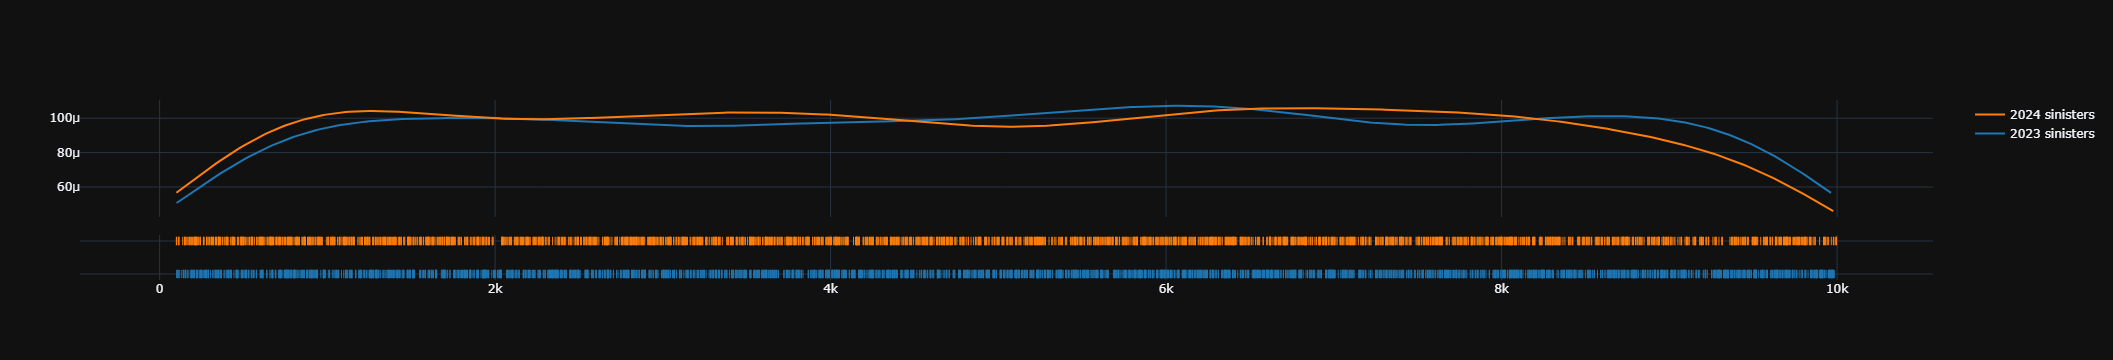

In [68]:
hist_data = [sorted_merged_data[2023][1], sorted_merged_data[2024][1]]
group_labels = ["2023 sinisters", "2024 sinisters"]
fig = ff.create_distplot(hist_data, group_labels, show_hist=False)
fig.update_layout(template="plotly_dark")
fig.show()

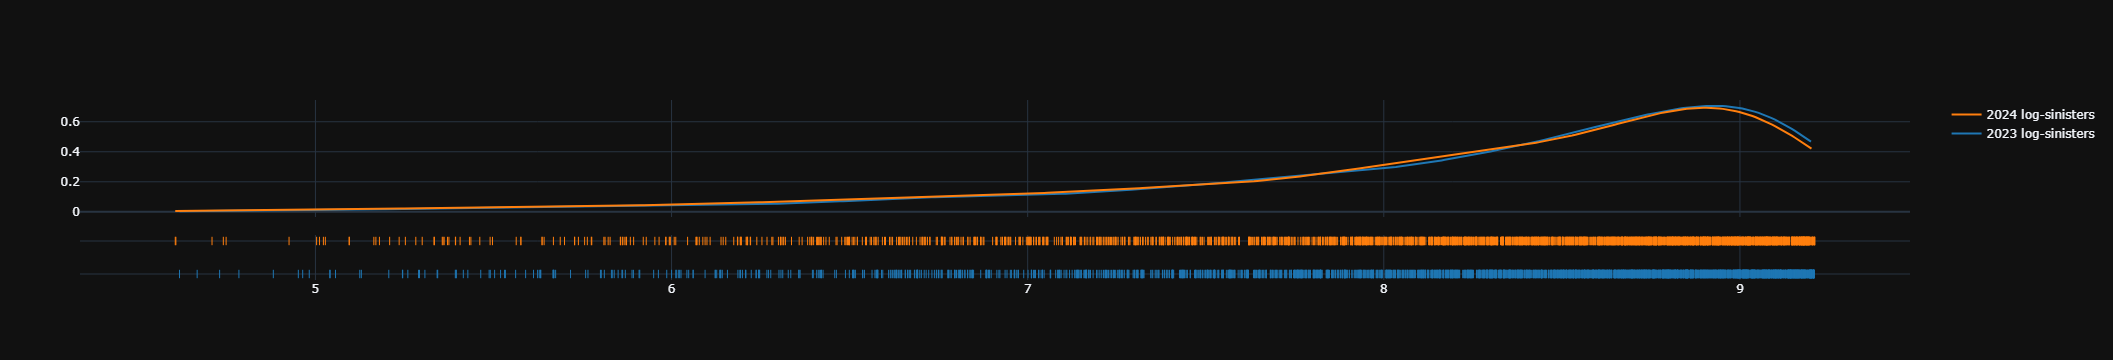

In [69]:
hist_data = [[math.log(a) for a in sorted_merged_data[2023][1]], [math.log(a) for a in sorted_merged_data[2024][1]]]
group_labels = ["2023 log-sinisters", "2024 log-sinisters"]
fig = ff.create_distplot(hist_data, group_labels, show_hist=False)
fig.update_layout(template="plotly_dark")
fig.show()

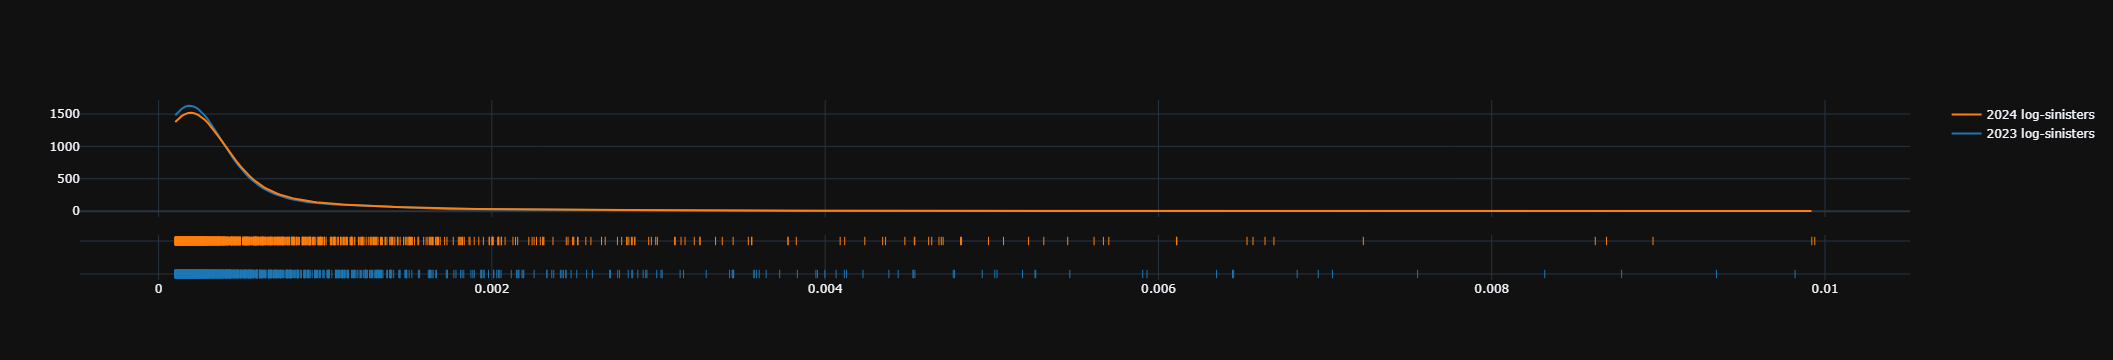

In [77]:
hist_data = [[math.log(1 + 1/a) for a in sorted_merged_data[2023][1]], [math.log(1 + 1/a) for a in sorted_merged_data[2024][1]]]
group_labels = ["2023 log-sinisters", "2024 log-sinisters"]
fig = ff.create_distplot(hist_data, group_labels, show_hist=False)
fig.update_layout(template="plotly_dark")
fig.show()

In [80]:
1 - max([1/a for a in sorted_merged_data[2023][1]])

0.9901312543175762

In [86]:
stats.shapiro([math.log(x) for x in [math.log(1 + 1/a) for a in sorted_merged_data[2023][1]]])

ShapiroResult(statistic=np.float64(0.8606359783280888), pvalue=np.float64(3.2665402022492174e-41))

In [90]:
n = len(sorted_merged_data[2023][1])
m1, m2 = sum(sorted_merged_data[2023][1])/n, sum([a**2 for a in sorted_merged_data[2023][1]])/n 
def get_model_estimation(t : float):
    return math.sqrt(intensity_integral(t))*(norm.ppf(0.95, loc=0, scale=1)*math.sqrt(m2) + math.sqrt(intensity_integral(t))*m1)/t

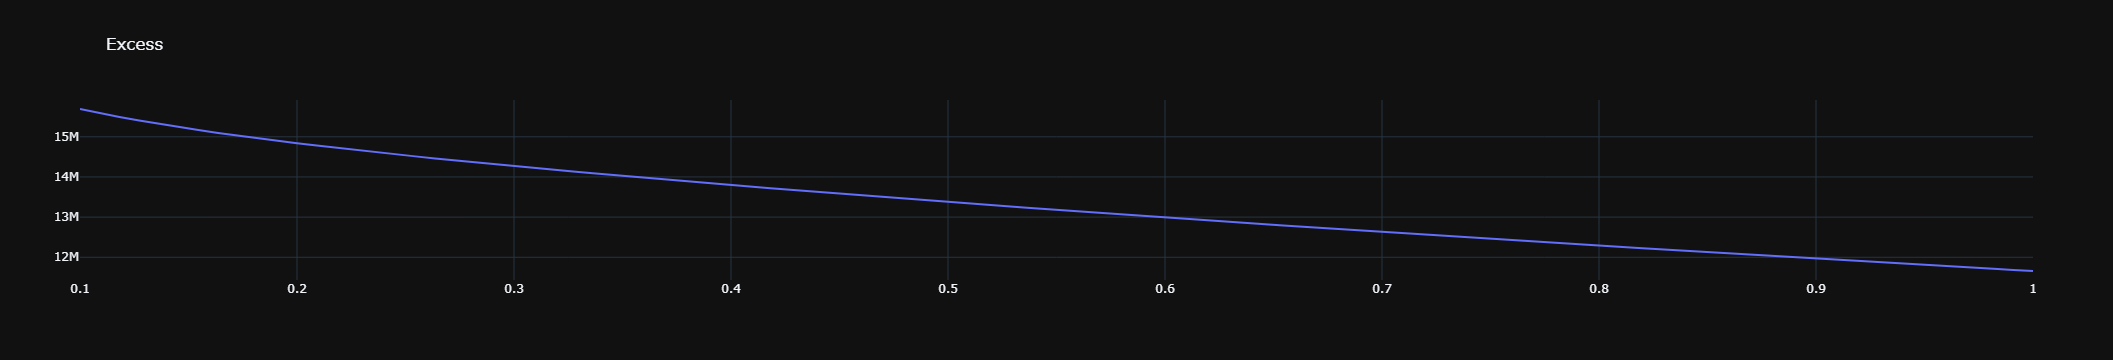

In [92]:
t = np.linspace(start=0.1, stop=1, num=100)
fig = go.Figure(data=go.Scatter(
    x=t,
    y=[get_model_estimation(a) for a in t]))
fig.update_layout(
    title=dict(text="Excess"),
    template="plotly_dark")
fig.show()

In [ ]:
L = 6000
m1, m2 = sum([(a<L)*a + L*(a>=L) for a in sorted_merged_data[2023][1]])/n, sum([a**2 for a in sorted_merged_data[2023][1]])/n 